In [4]:
## Creating tools

from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper 

In [5]:
# Tool-1
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=5, doc_content_chars_max=200)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv, description="Query arxiv papers")
print(arxiv.name)

arxiv


In [6]:
arxiv.invoke('Redemption all you need')

'Published: 2020-05-14\nTitle: Street Marketing: How Proximity and Context drive Coupon Redemption\nAuthors: Sarah Spiekermann, Matthias Rothensee, Michael Klafft\nSummary: Purpose: In 2009, US coupons se'

In [7]:
# Tool-2
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=200)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki.name)

wikipedia


In [8]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [9]:
## Tavily Search tool 
# Tool-3
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

C:\Users\Nikhil Ambure\AppData\Local\Temp\ipykernel_12172\207757377.py:5: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [10]:
tavily.invoke('Provide me the recent ai news')

[{'title': 'March 2026 AI News Roundup: Breakthroughs and the Fights, Forecasts, and Fears - Peterson Technology Partners',
  'url': 'https://www.ptechpartners.com/2026/04/07/march-2026-ai-news-roundup-breakthroughs-and-the-fights-forecasts-and-fears/',
  'content': '“There’s a lot of companies that are doing layoffs right now andblaming it on AI. But they’re actually doing layoffs because the businesses aren’t performing particularly well. And it’s a convenient excuse.” \n\nCount OpenAI among companies that are hiring, with The Information reporting the leading AI firm is looking to nearly double its headcount(4,500 to 8,000) by the end of 2026. \n\nOthers, like Circle Co-Founder and CEO Jeremy Allaire, see AI agents soon replacing a “huge percentage of work that’s currently performed by humans on a massive scale” (Yahoo Finance interview from March).  \n\nBlackRock CEO Larry Fink noted in his annual letter to shareholders that AI is leading to “K-shaped” results for companies, too, w

In [11]:
## combine all the tools in the list
tools = [arxiv, wiki, tavily]

In [12]:
## Initialize the llm model
from langchain_groq import ChatGroq

llm = ChatGroq(model='llama-3.1-8b-instant')

In [13]:
llm.invoke("What is AI")

AIMessage(content='AI, or Artificial Intelligence, refers to the simulation of human intelligence in machines that are programmed to think and learn like humans. The term can also be applied to any machine that exhibits traits associated with a human mind such as learning and problem-solving.\n\nAI technology is based on the principle of creating algorithms that enable computers to perform tasks that typically require human intelligence, such as:\n\n1. **Learning**: AI systems can learn from data, experience, and feedback to improve their performance over time.\n2. **Problem-solving**: AI systems can analyze data, identify patterns, and make decisions to solve complex problems.\n3. **Reasoning**: AI systems can use logic and rules to draw conclusions and make decisions.\n4. **Perception**: AI systems can interpret and understand data from sensors, such as images, speech, and text.\n\nThere are several types of AI, including:\n\n1. **Narrow or Weak AI**: Designed to perform a specific t

In [14]:
# llm will have the info about the tools
llm_with_tools = llm.bind_tools(tools=tools) 

In [15]:
# Excute the call
llm_with_tools.invoke("What is the recent news of ai?")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ft6cec732', 'function': {'arguments': '{"query":"AI recent news"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 461, 'total_tokens': 481, 'completion_time': 0.037484468, 'completion_tokens_details': None, 'prompt_time': 0.02889351, 'prompt_tokens_details': None, 'queue_time': 0.052915475, 'total_time': 0.066377978}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019decf7-6738-7461-a2d4-f43d49fbaf31-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'AI recent news'}, 'id': 'ft6cec732', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 461, 'output_tokens': 20, 'total_tokens': 481})

## Workflow (LangGraph)

In [16]:
## State Schema
from typing_extensions import TypedDict 
from typing import Annotated ## Labelling
from langchain_core.messages import AnyMessage, HumanMessage ## AnyMessage : Human message or AI message
from langgraph.graph.message import add_messages ## Reducers in langGraph

In [17]:
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

    """ Reducers in LangGraph -> 
        - list[Anymessages] : it will append all the messages 
          whether it is ai or human with the help of the add_messages reducers.
        - add_messages reducer: It don't override the messages ; it 'append' the new message into messages
        - if we dont use the 'add_message' function then it will override the messages by adding list[AnyMessage]
          that appeares. 
    """

In [18]:
## Entire Chatbot with LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition # for, when should we call the tool_node

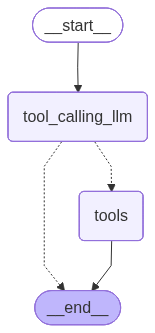

In [19]:
## Node Definition
def tool_calling_llm(state: State):
    return {'messages': [llm_with_tools.invoke(state["messages"])]}

## Build Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call => tools_condition routes to tools (by default)
    # if the latest message (result) from assistant is not a tool call => tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", END)

graph = builder.compile()

# View 
display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
# Run
messages = graph.invoke({"messages": "1706.03762"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (6stx8p9b2)
 Call ID: 6stx8p9b2
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The do


In [21]:
messages = graph.invoke({"messages": "Hi my name is Nick"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi my name is Nick
================================== Ai Message ==================================

I don't have any functions to call that are directly related to the name "Nick".


### ReAct Architecture

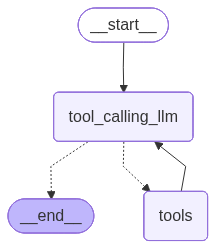

In [22]:
##  ReAct Architecture

## Node Definition
def tool_calling_llm(state: State):
    return {'messages': [llm_with_tools.invoke(state["messages"])]}

## Build Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call => tools_condition routes to tools (by default)
    # if the latest message (result) from assistant is not a tool call => tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm") # ***Going back to tool_calling_llm

# No need to add edge to 'End' it will go automatically//

graph = builder.compile()

# View 
display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
messages = graph.invoke({"messages": "What is the recent AI news and please tell me about the recent research paper on quantum computing?"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent AI news and please tell me about the recent research paper on quantum computing?
================================== Ai Message ==================================
Tool Calls:
  arxiv (dndk8ep2g)
 Call ID: dndk8ep2g
  Args:
    query: quantum computing recent research paper
  tavily_search_results_json (p0a6x8d94)
 Call ID: p0a6x8d94
  Args:
    query: recent AI news
================================= Tool Message =================================
Name: arxiv

Published: 2025-04-07
Title: Quantum Computing: Vision and Challenges
Authors: Sukhpal Singh Gill, Oktay Cetinkaya, Stefano Marrone, Daniel Claudino, David Haunschild, Leon Schlote, Huaming Wu, Carlo 
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI News & Artificial Intelligence | TechCrunch", "url": "https://techcrunch.com/category/artificial-intellige

### Adding Memory in Agentic Graph 

In [24]:
messages = graph.invoke({"messages": "Hello, my name is Nick"})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello, my name is Nick
================================== Ai Message ==================================

You didn't ask a question or make a function call. I'll wait for your next request.


In [25]:
# It is not able to answer based on the previous conversation now
messages = graph.invoke({"messages": "What is my name?"}) 
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (56gatt8y6)
 Call ID: 56gatt8y6
  Args:
    query: your name
  wikipedia (zk0kf3hs5)
 Call ID: zk0kf3hs5
  Args:
    query: user name
================================= Tool Message =================================
Name: wikipedia

Page: Your Name
Summary: Your Name (Japanese: 君の名は。, Hepburn: Kimi no Na wa; lit. 'Your Name is...') is a 2016 Japanese animated romantic fantasy film written and directed by Makoto Shinkai, produced 
================================= Tool Message =================================
Name: wikipedia

Page: User (computing)
Summary: A user is a person who uses a computer or network service. A user typically has a user account and is recognized by the system through a username. Some software product
================================== Ai Message ==================

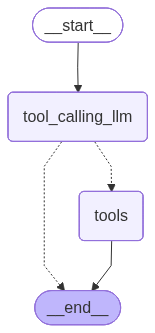

In [26]:
# Now, by using MemoryaSaver checkpoint
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

# Graph
## Node Definition
def tool_calling_llm(state: State):
    return {'messages': [llm_with_tools.invoke(state["messages"])]}

## Build Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call => tools_condition routes to tools (by default)
    # if the latest message (result) from assistant is not a tool call => tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", END)

# Add memory saver checkpoint
graph = builder.compile(checkpointer=memory)

# View 
display(Image(graph.get_graph().draw_mermaid_png()))

In [27]:
config = {"configurable": {"thread_id": "1"}} # thread id should be unique

messages = graph.invoke({'messages': "Hi, my name is Nick"}, config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hi, my name is Nick
================================== Ai Message ==================================

(function=wikipedia>{"query": "Nick"}</function>


In [28]:
messages['messages'][-1]

AIMessage(content='(function=wikipedia>{"query": "Nick"}</function>', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 459, 'total_tokens': 472, 'completion_time': 0.028096957, 'completion_tokens_details': None, 'prompt_time': 0.02638703, 'prompt_tokens_details': None, 'queue_time': 0.051732229, 'total_time': 0.054483987}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019decf7-dc84-7030-951b-8df9495c34ed-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 459, 'output_tokens': 13, 'total_tokens': 472})

In [29]:
messages = graph.invoke({'messages': "What is my name?"}, config=config)

messages['messages'][-1]
# Now it can remember your name

AIMessage(content='Your name is Nick.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 6, 'prompt_tokens': 486, 'total_tokens': 492, 'completion_time': 0.012813003, 'completion_tokens_details': None, 'prompt_time': 0.028070227, 'prompt_tokens_details': None, 'queue_time': 0.052549623, 'total_time': 0.04088323}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019decf7-f1c5-7da0-9914-092f3fc93e16-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 486, 'output_tokens': 6, 'total_tokens': 492})

In [30]:
messages = graph.invoke({'messages': "Do you remember my name?"}, config=config)

messages['messages'][-1]

AIMessage(content='(function=wikipedia>{"query": "Nick"}</function>', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 507, 'total_tokens': 520, 'completion_time': 0.019573048, 'completion_tokens_details': None, 'prompt_time': 0.032049676, 'prompt_tokens_details': None, 'queue_time': 0.051902649, 'total_time': 0.051622724}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019decf8-028c-79d1-9cea-c3aa4b281349-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 507, 'output_tokens': 13, 'total_tokens': 520})

### Streaming

Methods: .stream() and .astream()
- These methods are sync and async methods for streaming back results

Additional parameters in streaming modes for graph state
- values : This streams the full state of the graph after each node is called.
- updates : This streams updates to the state of the graph after each node is called.

In [32]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [33]:
def superbot(state: State):
    return {'messages': [llm.invoke(state["messages"])]}

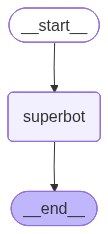

In [34]:
graph = StateGraph(State)

# Node
graph.add_node("superbot", superbot)

## Edges
graph.add_edge(START, "superbot")
graph.add_edge("superbot", END)

graph_builder = graph.compile(checkpointer=memory)

## display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [35]:
# Invocation

config = {"configurable": {"thread_id": "1"}} # thread id should be unique

graph_builder.invoke({"messages": "Hi, my name is Nick And I like cricket"}, config=config)

{'messages': [HumanMessage(content='Hi, my name is Nick And I like cricket', additional_kwargs={}, response_metadata={}, id='84908c5d-2649-4e38-a783-0b1d77e99b7e'),
  AIMessage(content="Hello Nick, nice to meet you. That's great to hear you like cricket! Cricket is a fascinating sport with a rich history and a huge following around the world. Which aspect of cricket do you enjoy the most - the technical aspect, watching international matches, or playing with friends?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 45, 'total_tokens': 103, 'completion_time': 0.103038478, 'completion_tokens_details': None, 'prompt_time': 0.002166757, 'prompt_tokens_details': None, 'queue_time': 0.052507453, 'total_time': 0.105205235}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019decf9-2159-7333-a28d-169764996

### Streaming

In [36]:
## stream() method

config = {"configurable": {"thread_id": "3"}}

# Mode = "updates"
for chunk in graph_builder.stream({"messages": "What is the recent news of AI?"}, config=config, stream_mode="updates"):
    print(chunk)
    # Whichever message is the last message, that will be the final response of the graph. 
    # It is because of the stream_mode="updates" that we are getting the intermediate messages 
    # as well as the final message. If we use stream_mode="final" then we will get only the final message.

{'superbot': {'messages': [AIMessage(content="There are numerous recent developments in the field of Artificial Intelligence (AI). Here are some of the key updates:\n\n1. **Advancements in Large Language Models**: Google's LaMDA (Large Language Model Dialogue Applications), Meta's Llama, and Microsoft's Turing-NLG are among the recent large language models that have shown significant improvements in natural language processing and generation capabilities.\n2. **AI-Powered Chatbots**: Companies like Meta, Microsoft, and Google have introduced AI-powered chatbots that can engage in human-like conversations, providing customer support and answering queries.\n3. **Emergence of Explainable AI (XAI)**: XAI is a new approach that aims to make AI more transparent and explainable. This is crucial for building trust in AI systems, especially in high-stakes applications like healthcare and finance.\n4. **Advances in Computer Vision**: Researchers have made significant progress in computer vision,

In [37]:
# Mode = "values"

for chunk in graph_builder.stream({"messages": "What is the recent news of AI?"}, config=config, stream_mode="values"):
    print(chunk)
    # All the messages that appeares in the stream will be printed whether it is intermediate or final message.

{'messages': [HumanMessage(content='What is the recent news of AI?', additional_kwargs={}, response_metadata={}, id='6a078d2c-b945-4c3c-be17-038d5cb4b270'), AIMessage(content="There are numerous recent developments in the field of Artificial Intelligence (AI). Here are some of the key updates:\n\n1. **Advancements in Large Language Models**: Google's LaMDA (Large Language Model Dialogue Applications), Meta's Llama, and Microsoft's Turing-NLG are among the recent large language models that have shown significant improvements in natural language processing and generation capabilities.\n2. **AI-Powered Chatbots**: Companies like Meta, Microsoft, and Google have introduced AI-powered chatbots that can engage in human-like conversations, providing customer support and answering queries.\n3. **Emergence of Explainable AI (XAI)**: XAI is a new approach that aims to make AI more transparent and explainable. This is crucial for building trust in AI systems, especially in high-stakes application

In [ ]:
# astream_events() method

config = {"configurable": {"thread_id": "4"}}

async for chunk in graph_builder.astream_events({"messages": "What is the recent news of AI?"}, config, version="v2"):
    print(chunk)
# For debugging purpose, we can use stream() method and for production use astream_events() method.

{'event': 'on_chain_start', 'data': {'input': {'messages': 'What is the recent news of AI?'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019ded01-7df1-7861-a50c-90ed136e0db2', 'metadata': {'thread_id': '4', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='What is the recent news of AI?', additional_kwargs={}, response_metadata={}, id='84c6e802-2b9f-45a4-b1f7-367deda82eb8')]}}, 'name': 'superbot', 'tags': ['graph:step:1'], 'run_id': '019ded01-7df4-7dd1-822e-484ede90ae24', 'metadata': {'thread_id': '4', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'superbot', 'langgraph_triggers': ('branch:to:superbot',), 'langgraph_path': ('__pregel_pull', 'superbot'), 'langgraph_checkpoint_ns': 'superbot:df25c335-f5b1-8bff-d95d-f1a353bf1b17'}, 'parent_ids': ['019ded01-7df1-7861-a50c-90ed136e0db2']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='What is t